# Desicion Trees

---

Flowchart-like model used to make predictions and desicions by breaking data down into step-by-step choices.

![visualization](../../assets/decision_tree.webp)

##### Node attributes:
- *samples*: the number of training instances in this node
- *values*: the number of training instances *per class* in this node
- *gini*: impurity measure 
- *class*: majority class

##### How it works:

At each node starting from the root a question is asked. If True left, else right. The classification is made once we reach a leaf node.

They require no scaling / centering.

##### Main benefits:
- explainability by readability
- flexibility to learn complex non-linear associations 

It returns probabilities based on the leaf's impurity (gini). For example at the green leaf it gives probabilities: 0% for Iris setosa (0/54), 90.7% for Iris versicolor (49/54), and 9.3% for Iris virginica (5/54).

##### How the split is made:

- Classification: a split is made based on the impurity of the node measured by gini or entropy.
    - **gini**: [0, 1]. 0 -> pure. $$G_i = 1 - \sum_{k=1}^{n}p_{i,k}^2$$where $p_{i,k}$ is the ration of class k instances in the sample of node i.
    - **entropy**: [0, 1]. 0 -> pure. $$H_i = -\sum_{k=1}^{n}p_{i,k}log_2(p_{i,k})$$for $p_{i,k} \neq 0$

##### Gini vs Entropy:

Both are produce very similar trees. Gini is slightly faster but tends to isolate the most frequent class in its own branch while entropy tends to produce more balanced trees.

- Regression: a split is made based on the mse of the node

##### Regularization hyperparameters:

Very important because trees are prone to overfitting
- `max_depth`: tunes the maximum depth of the tree. Large depth results in a more complex tree (prone to overfitting) while small to underfitting.
- `min_samples_split`: the minimum number of instances in a node to split it
- `min_samples_leaf`: the minimum number of instances in a leaf to make a split (similar to `min_weight_fraction_leaf` which is the same but as a fraction to the total number of weighted instances)
- `max_leaf_nodes`
- `max_features`: the maximum number of features used for each split

In a nutshell increasing `min_*` or reducing `max_*` hyperparameters regularizes the model.

In [1]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree, DecisionTreeRegressor
from sklearn.metrics import accuracy_score

import matplotlib.pyplot as plt

In [2]:
RANDOM_SEED = 42

In [3]:
iris = load_iris()

X, y = iris.data, iris.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.35, random_state=RANDOM_SEED)

In [4]:
X.shape

(150, 4)

We see that we have 150 instances. This means that the maximum depth would be around $ceil(log_2(150)) = 8$. So we try max depths of 2, 3, 4.

In [5]:
param_grid = {
    "max_depth": [2, 3, 4],
}

grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=RANDOM_SEED),
    param_grid=param_grid,
    scoring="accuracy",
)

grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best train accuracy during cv: {grid_search.best_score_}")

y_pred = best_model.predict(X_test)
print(f"Test accuracy: {accuracy_score(y_test, y_pred)}")

Best parameters: {'max_depth': 3}
Best train accuracy during cv: 0.9394736842105263
Test accuracy: 0.9811320754716981


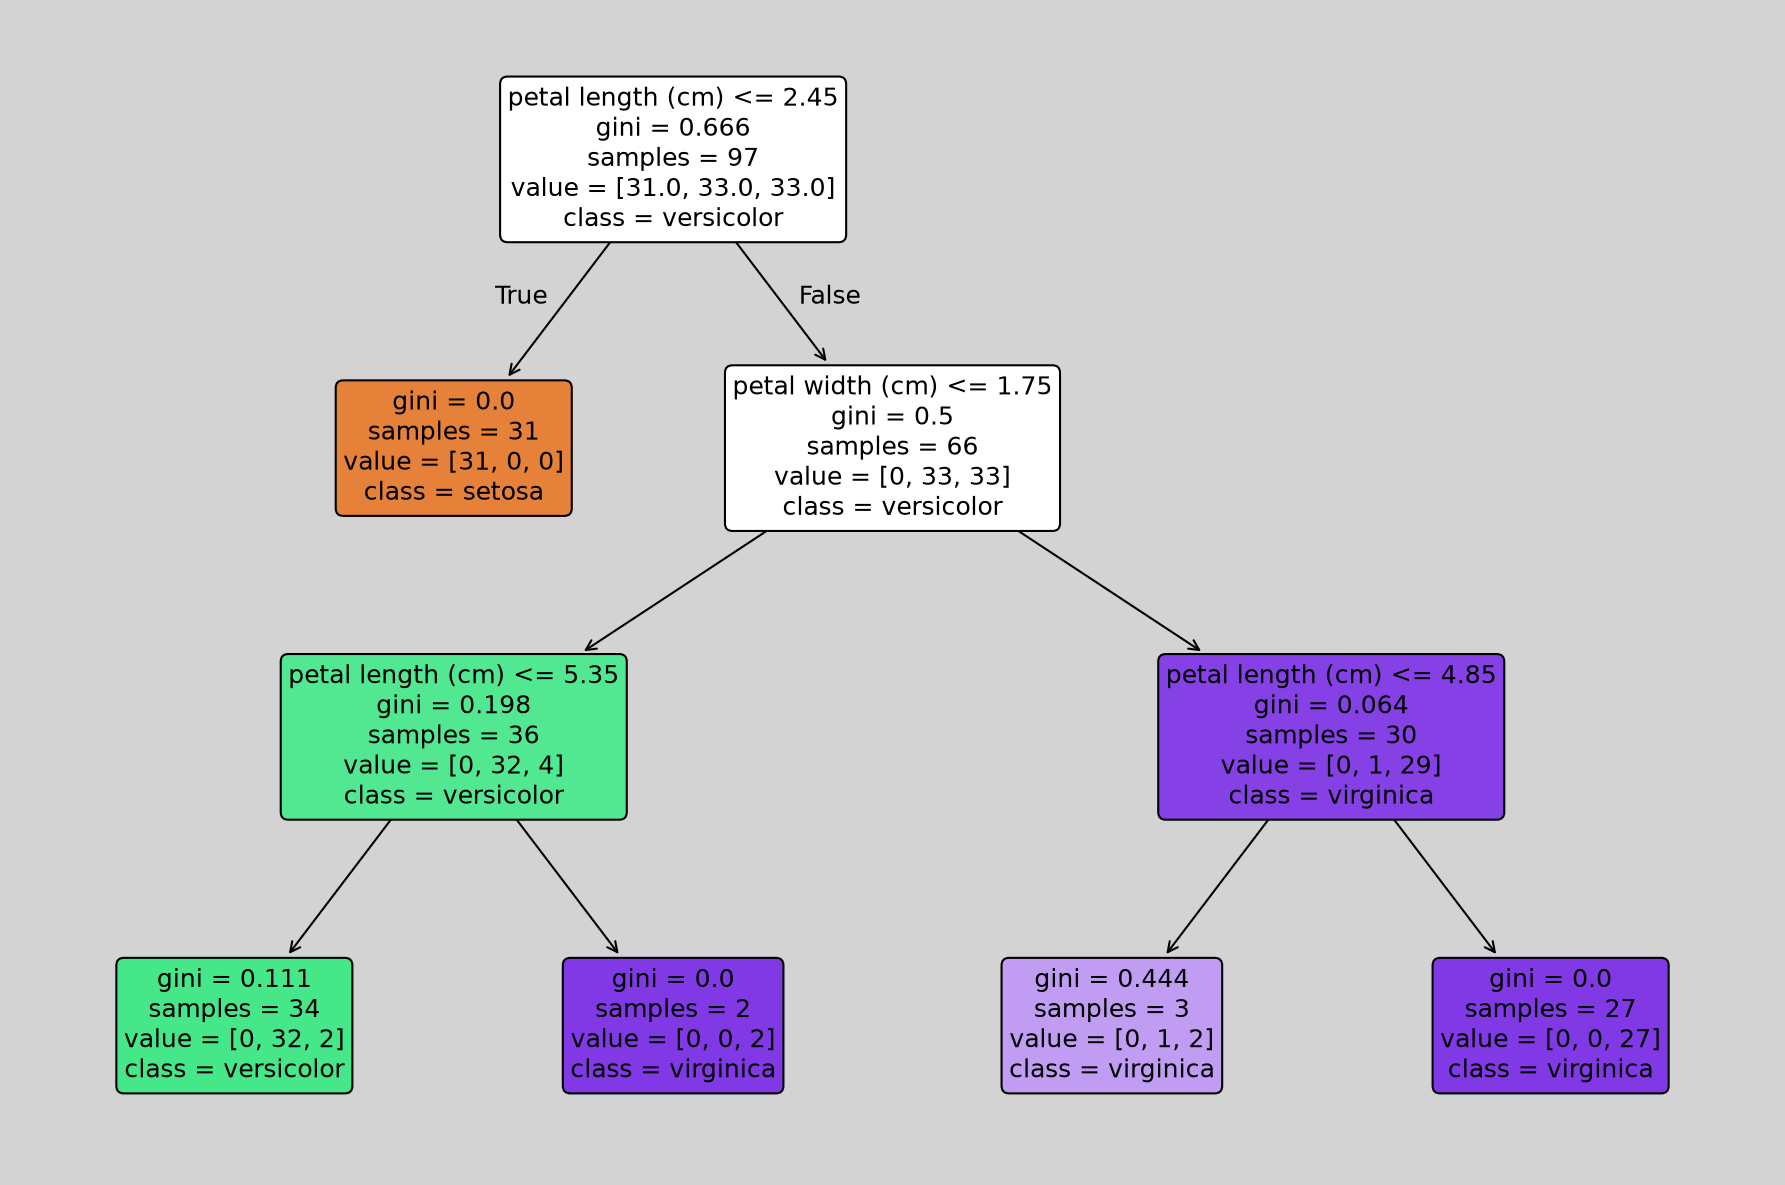

In [6]:
plt.figure(figsize=(12,8), facecolor="lightgray", dpi=150)
plot_tree(
    decision_tree=best_model,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True,
    impurity=True,
    rounded=True,
)
plt.tight_layout()
plt.show()

From the visualization we see that the model is overfitting a little bit despite the really high test accuracy

In [7]:
tree = DecisionTreeClassifier(max_depth=2, random_state=RANDOM_SEED)
tree.fit(X_train, y_train)

y_pred = tree.predict(X_train)
print(f"Train accuracy: {accuracy_score(y_train, y_pred)}")
y_pred = tree.predict(X_test)
print(f"Test accuracy: {accuracy_score(y_test, y_pred)}")

Train accuracy: 0.9484536082474226
Test accuracy: 0.9811320754716981


Almost same test accuracy

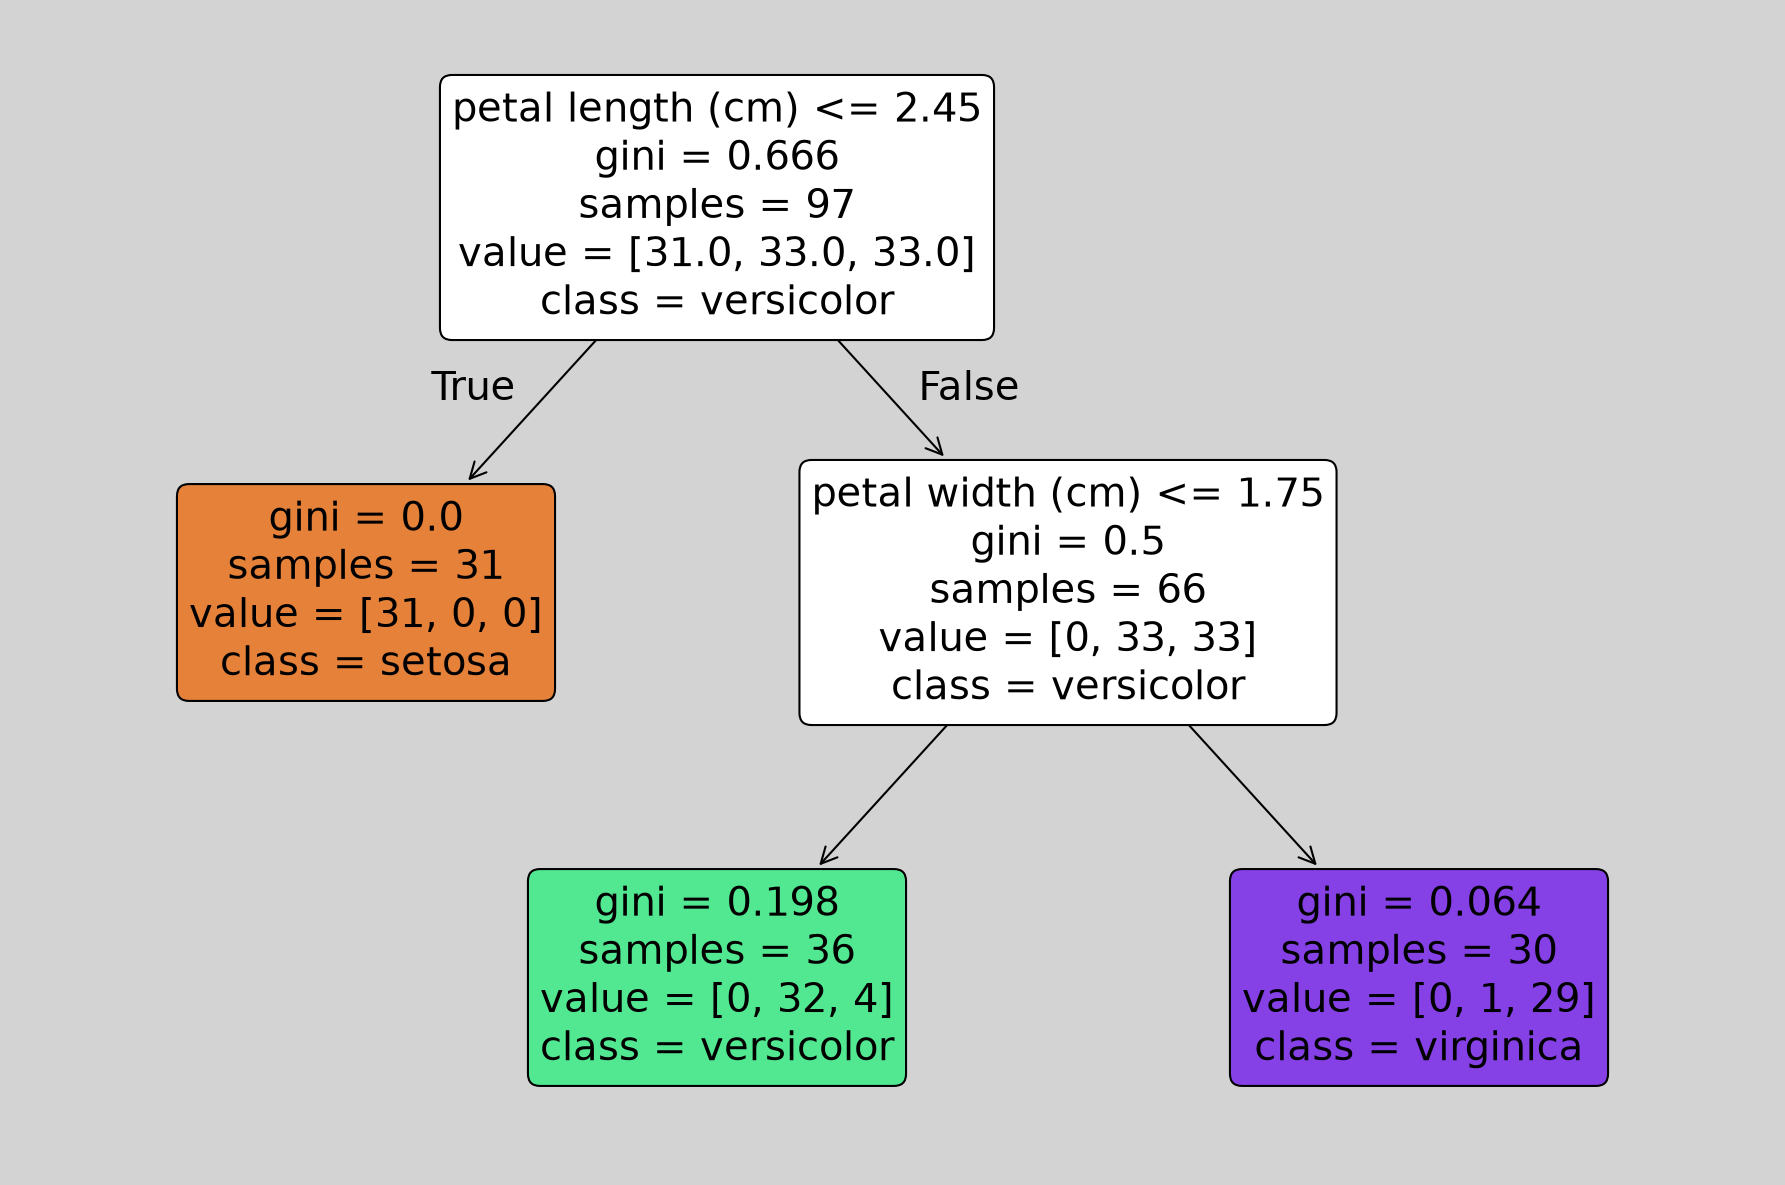

In [8]:
plt.figure(figsize=(12,8), facecolor="lightgray", dpi=150)
plot_tree(
    decision_tree=tree,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True,
    impurity=True,
    rounded=True,
)
plt.tight_layout()
plt.show()